In [ ]:
from typing import Callable

from numpy.typing import NDArray
import numpy as np

from bloodmoon.coords import angle2shift, shift2pos
from bloodmoon.mask import CodedMaskCamera, codedmask
from bloodmoon.optim import model_sky

import darksun as ds

ds.show.set_figures_darkbkg()

In [2]:
MASK_FITS: str = "wfm_mask_NTHT_20250725.fits"
MASK_FITS_corrct: str = "mask_050_1040x17_20260129_CORRECTED.fits"

UPS_X: int = 10
UPS_Y: int = 5

basepath: str = (
    '/mnt/dbb8f47e-da06-47bf-8ef5-038092af70f7/Edos_Magnificent_Manor/PhD_AASS/Coding/IROS_Data/Simulations'
)
wfm: CodedMaskCamera = codedmask(f'{basepath}/{MASK_FITS}', UPS_X, UPS_Y)
wfm_corrct: CodedMaskCamera = codedmask(f'{basepath}/{MASK_FITS_corrct}', UPS_X, UPS_Y)

In [80]:
anglex, angley = 30.0, 30.0

shiftx, shifty = map(lambda x: angle2shift(wfm, x), (anglex, angley))
cts: float = 1e5

**Testing Source Reconstruction**

In [81]:
sky: NDArray = model_sky(wfm, shiftx, shifty, cts)
sky_corrct: NDArray = model_sky(wfm_corrct, shiftx, shifty, cts)

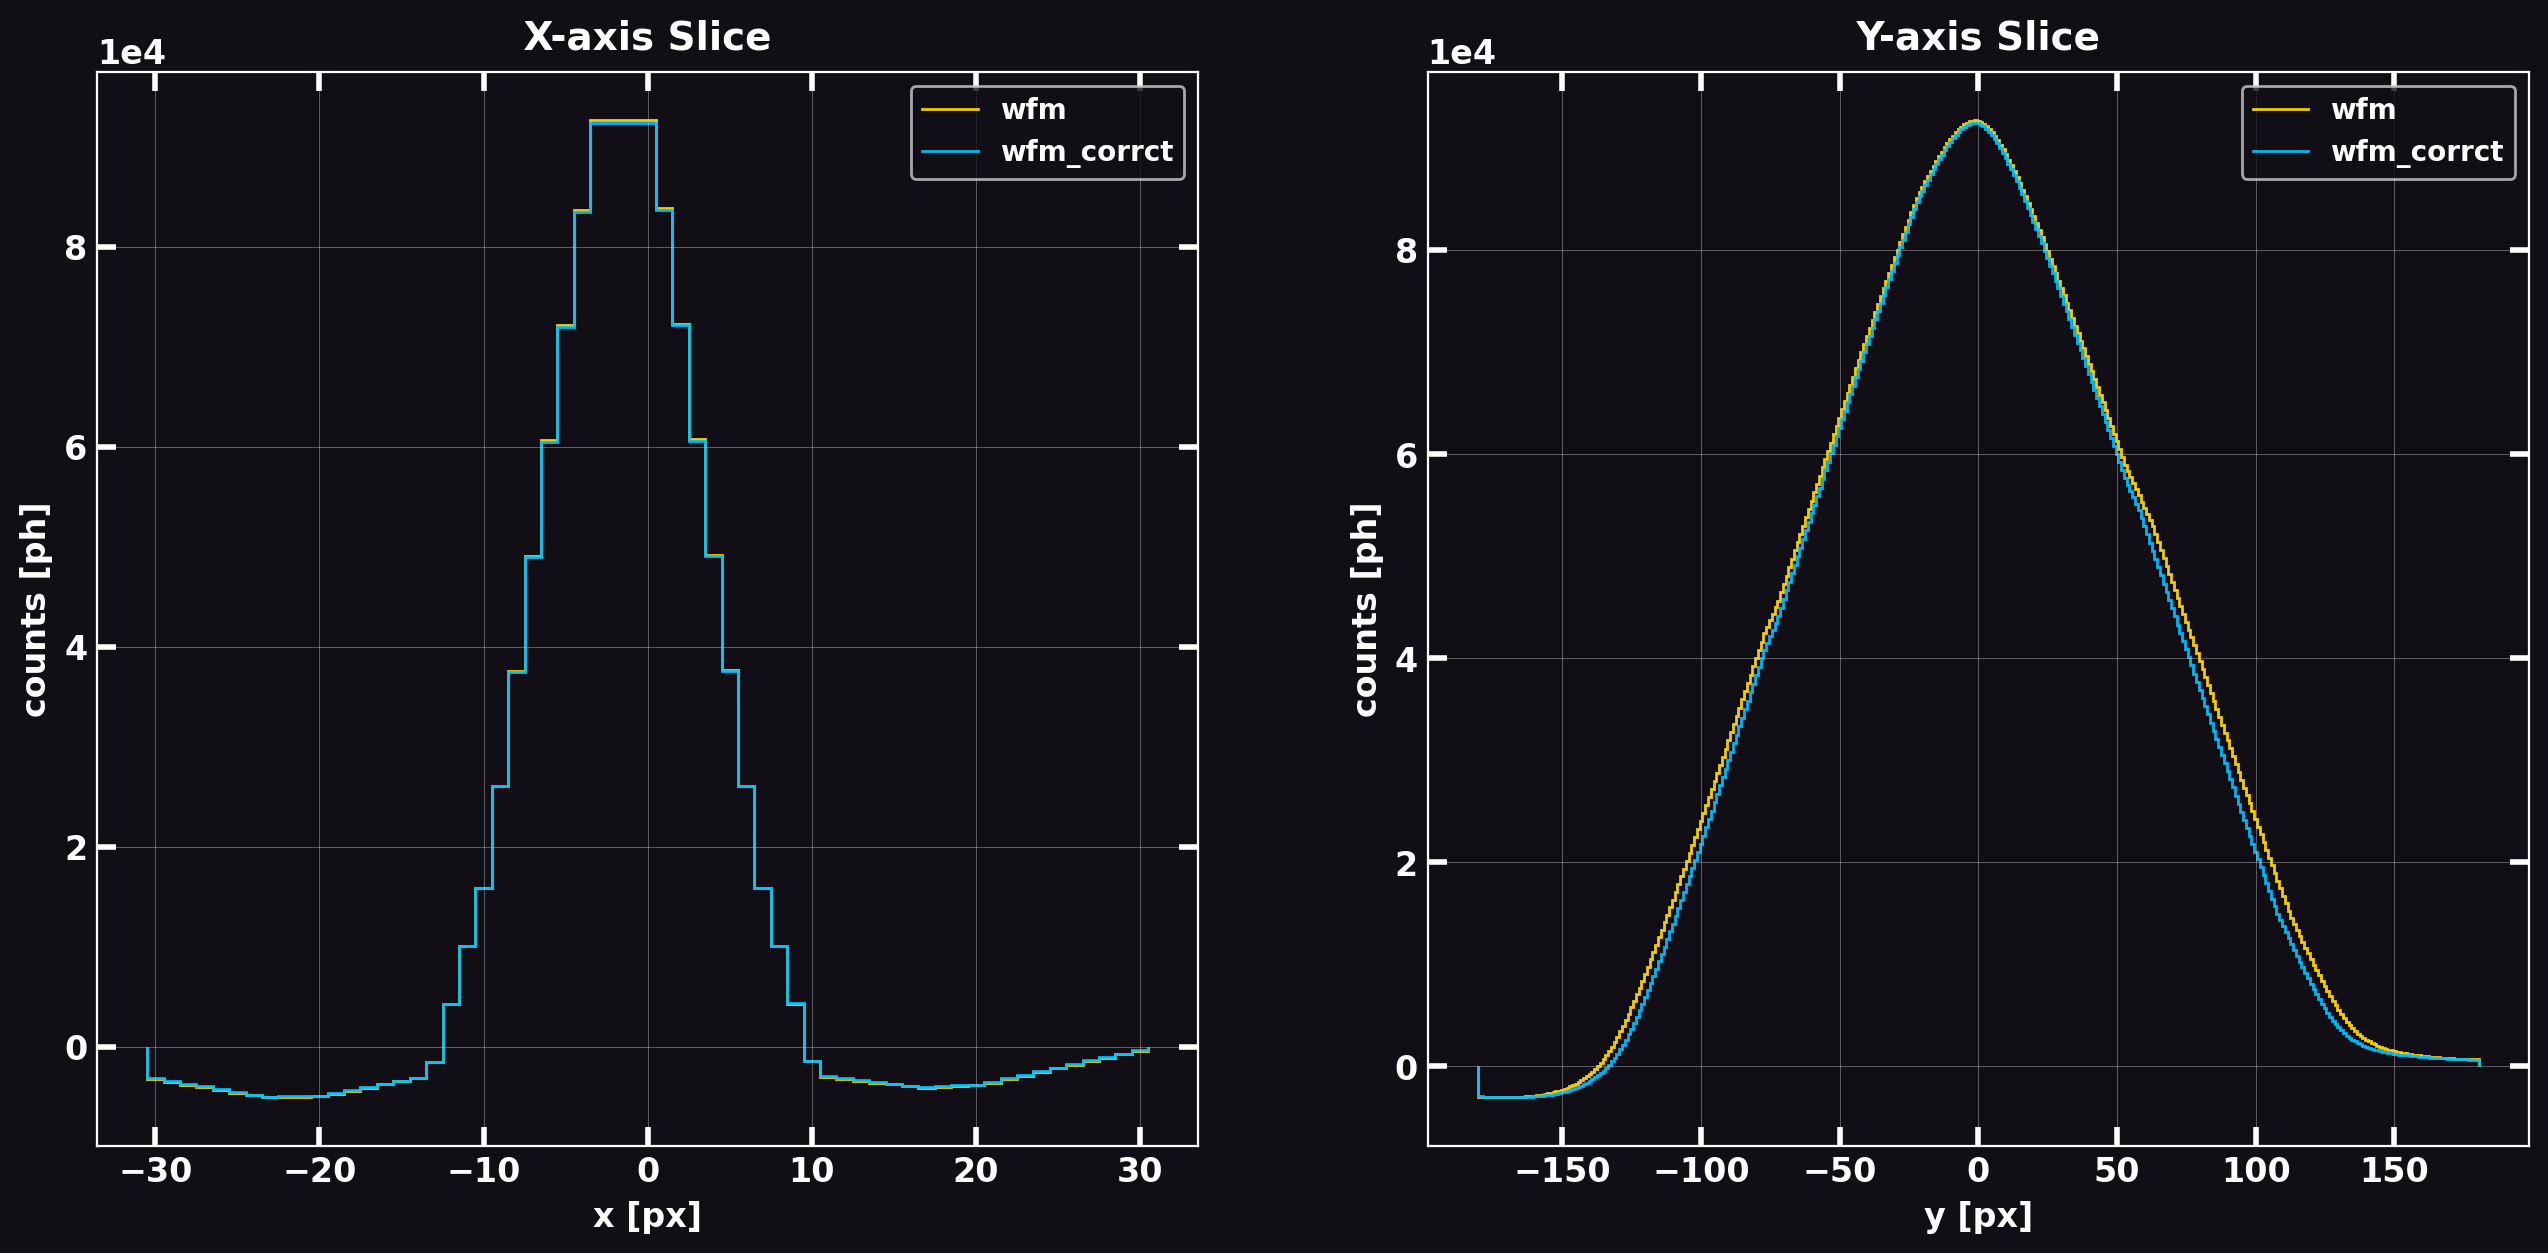

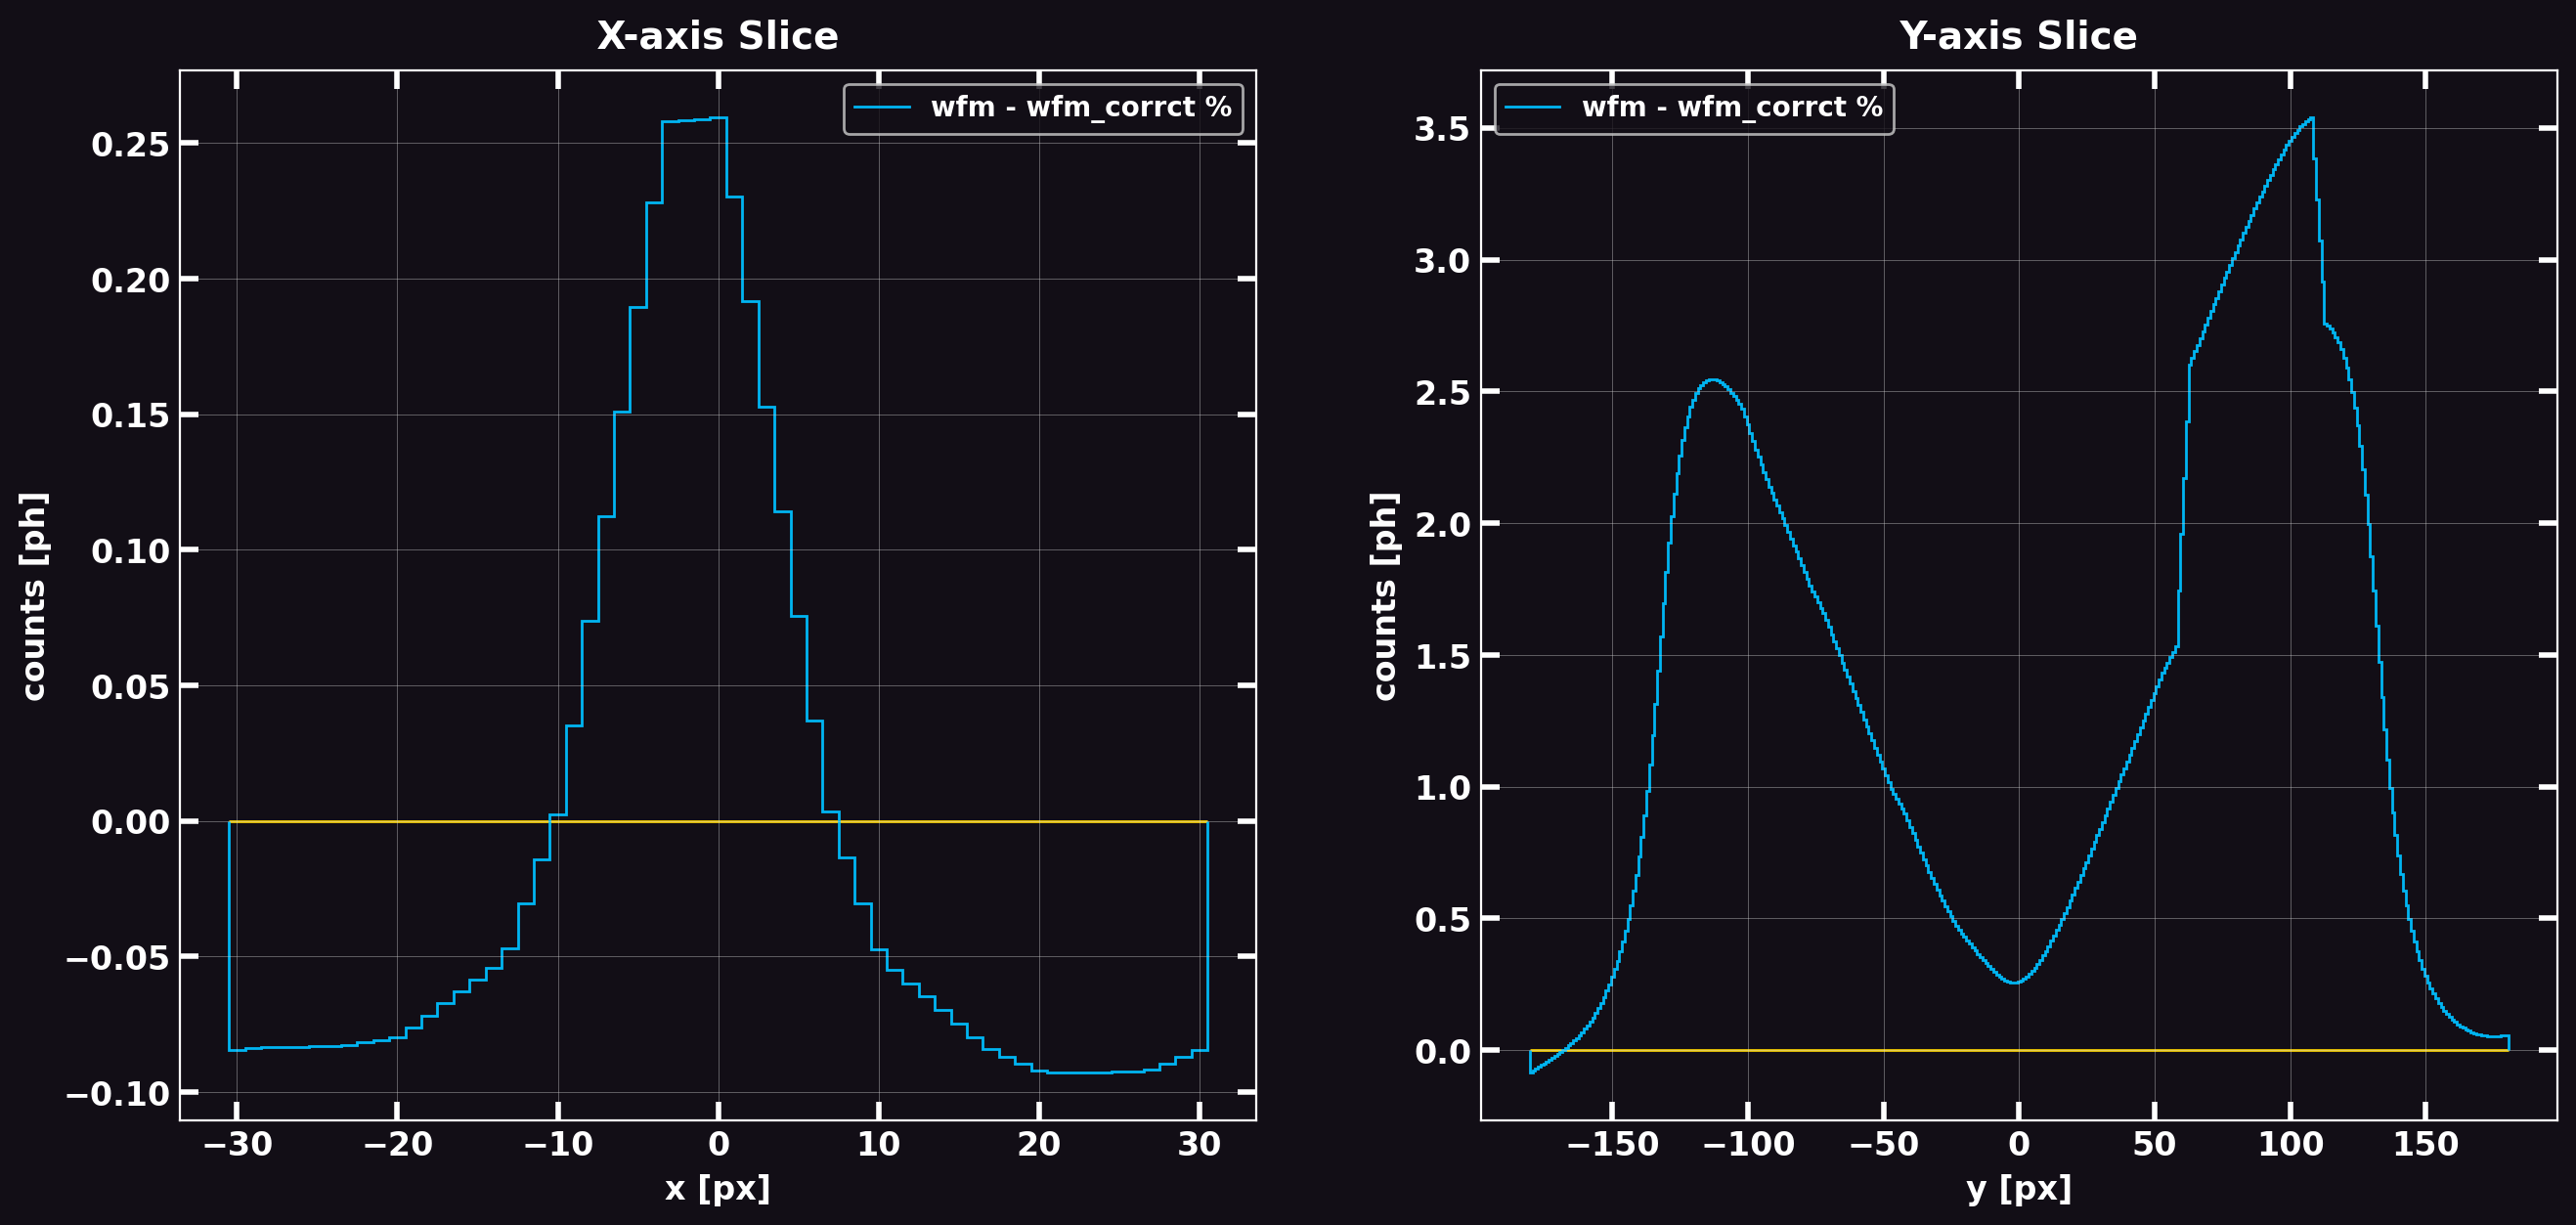

In [88]:
_psfextns = ds.psf_extension(wfm)[::-1]
_offset = (
    5 * wfm.upscale_f.y,
    2 * wfm.upscale_f.x,
)
_labels: dict = {
    'color': ('Gold', 'DeepSkyBlue'),
}
CRP = sum(map(np.array, (_psfextns, _offset)))
POS = shift2pos(wfm, shiftx, shifty) #argmax(sky)

ds.slices_plot(
    sky=(sky, sky_corrct),
    pos=POS,
    crp=CRP,
    labels=('wfm', 'wfm_corrct'),
    **_labels,
)
ds.slices_plot(
    sky=(np.zeros_like(sky), (sky - sky_corrct) * 100 / sky.max()),
    pos=POS,
    crp=CRP,
    labels=('', 'wfm - wfm_corrct %'),
    **_labels,
)

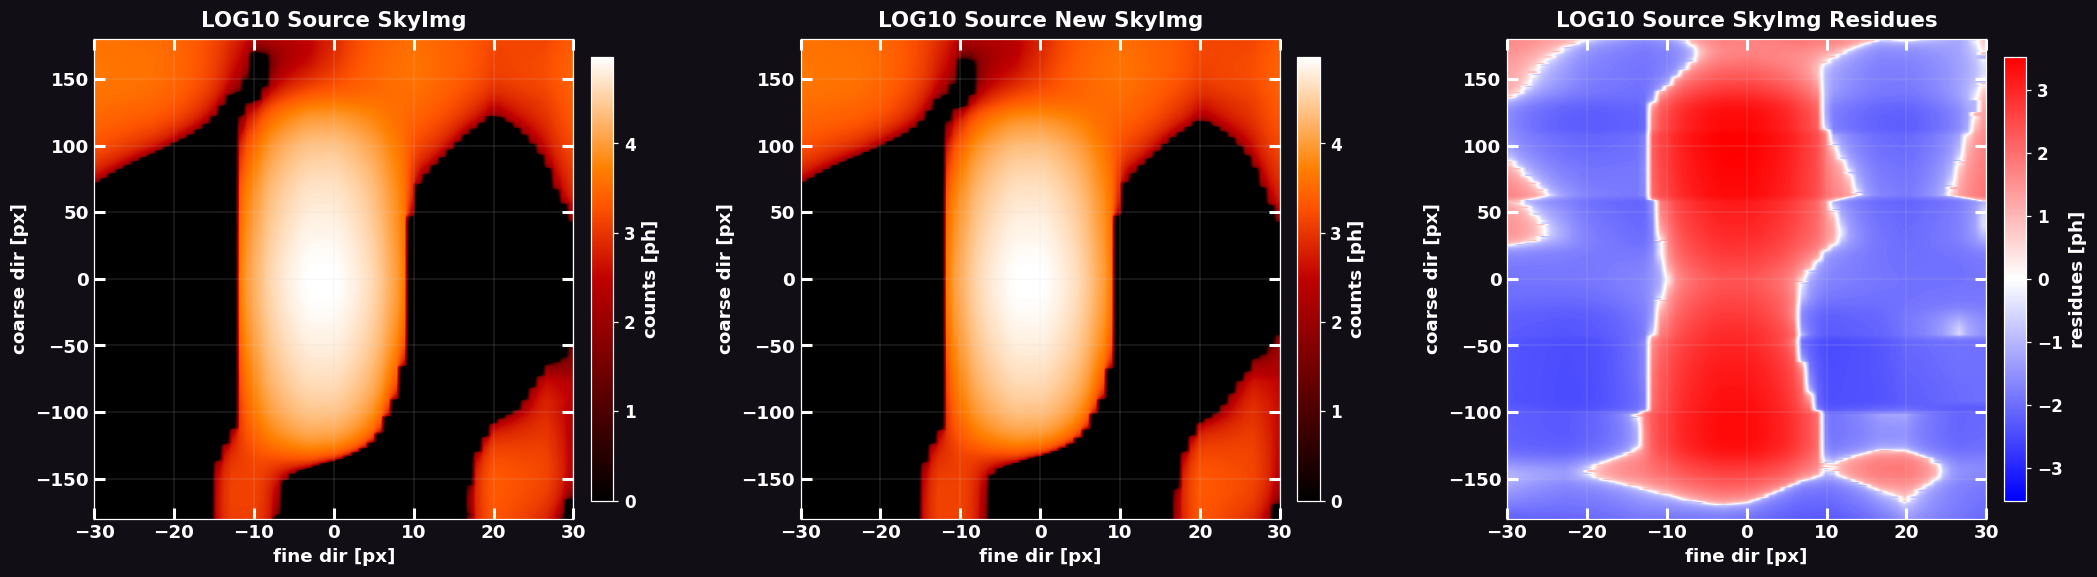

In [89]:
def mod_display(
    arr: NDArray,
    method: Callable[[NDArray], NDArray],
    lims: tuple[int, int] = (-1, 1),
) -> NDArray:
    """
    Processes the input arr values with given method
    (e.g., `np.log`, `lambda x: np.pow(x, exp)`).
    """
    low, high = lims
    out = np.empty_like(arr, dtype=float)
    negvals, posvals = (arr < low), (arr > high)
    out[negvals] = -method(np.abs(arr[negvals]))
    out[posvals] = method(arr[posvals])
    # handles in-between values
    inbetwvals = ~(negvals | posvals)
    out[inbetwvals] = np.where(arr[inbetwvals] <= 0.0, low, high)
    return out


sky_crp, sky_corrct_crp = map(
    lambda x: ds.crop(x, POS, CRP), (sky, sky_corrct),
)
res = sky_crp - sky_corrct_crp

_mthd: Callable = np.log10
sky_crp_, sky_corrct_crp_, res_ = map(
    lambda x: mod_display(x, _mthd), (sky_crp, sky_corrct_crp, res),
)

_labels: dict = {
    'xlabel': 'fine dir [px]',
    'ylabel': 'coarse dir [px]',
    'cbarlabel': 'counts [ph]',
}
_imgkwargs: dict = {
    'aspect': CRP[1] / CRP[0],
    'extent': [-CRP[1], CRP[1], -CRP[0], CRP[0]],
    'vmin': 0.0,
    'vmax': sky_crp_.max(),
    'cmap': 'gist_heat',
    'interpolation': 'bilinear',
}
vlim = np.max(np.abs(res_))

sky_dmaps = (
    ds.map4image(
        img=sky_crp_,
        title=f'{_mthd.__name__.upper()} Source SkyImg',
        img_kwargs=_imgkwargs,
        **_labels,
    ),
    ds.map4image(
        img=sky_corrct_crp_,
        title=f'{_mthd.__name__.upper()} Source New SkyImg',
        img_kwargs=_imgkwargs,
        **_labels,
    ),
    ds.map4image(
        img=res_,
        title=f'{_mthd.__name__.upper()} Source SkyImg Residues',
        xlabel=_labels['xlabel'],
        ylabel=_labels['ylabel'],
        cbarlabel='residues [ph]',
        img_kwargs={
            **_imgkwargs,
            'vmin': -vlim,
            'vmax': vlim,
            'cmap': 'bwr',
        },
    ),
)
ds.image_plot(
    dmaps=sky_dmaps,
    ncols=3,
)

**Testing Reconstruction Efficiency**

In [84]:
ideal_sky: NDArray = model_sky(wfm, shiftx, shifty, cts, vignetting=False, psfy=False)
ideal_sky_corrct: NDArray = model_sky(wfm_corrct, shiftx, shifty, cts, vignetting=False, psfy=False)

In [85]:
print(
    f'## Reconstruction Efficiency at {(anglex, angley)} deg:\n'
    
    f'  - input cts: {cts} ph\n\n'
    f'  - reconstructed at peak:\n'
    f'      * mask: {sky.max() * 100 / cts:.4f} %\n'
    f'      * mask (new): {sky_corrct.max() * 100 / cts:.4f} %\n\n'

    f'  - reconstructed at peak (ideal model):\n'
    f'      * mask: {ideal_sky.max() * 100 / cts:.4f} %\n'
    f'      * mask (new): {ideal_sky_corrct.max() * 100 / cts:.4f} %\n'
)

## Reconstruction Efficiency at (30.0, 30.0) deg:
  - input cts: 100000.0 ph

  - reconstructed at peak:
      * mask: 92.6623 %
      * mask (new): 92.4242 %

  - reconstructed at peak (ideal model):
      * mask: 97.4348 %
      * mask (new): 97.4085 %

